# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Leila | Tawfik | Leila Tawfik | Hours | Contribution |
| Member 2: | Saumyaa | Singla | Saumyaa Singla | Hours | Contribution |
| Member 3: | Daniel | Gabriel | Daniel Gabriel | Hours | Contribution |
| Member 4: | Elham | Maghsoudloo | Elham Maghsoudloo |  | Contribution |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

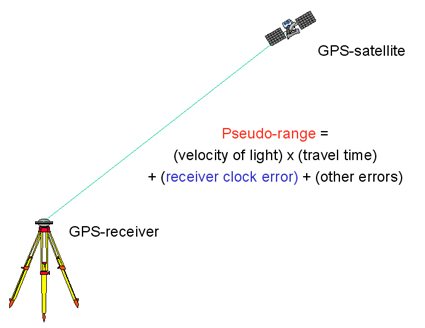

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
# Storing the pseudorange and satellite position excel files into dataframes
df_pseudorange = pd.read_excel('pseudoranges.xlsx')
df_sat_pos = pd.read_excel('satellite_position.xlsx')
# Checking data stored in the dataframes
df_pseudorange.head()
df_sat_pos.head()

np.random.seed(42)  # For reproducible results
# Converting pseudorange into a numpy array without satellite IDs
pseudorange_no_noise = df_pseudorange['P'].to_numpy()
# Creating an object to store the range for measurement noise and setting the shape to the pseudorange numpy array
noise = np.random.uniform(low=0, high=0.5, size=pseudorange_no_noise.shape)
# Adding the measurement noise to the pseudorange data
pseudorange = pseudorange_no_noise + noise
# Checking to see if the conversion and noise addition worked
print(pseudorange_no_noise)
print(pseudorange)

# Converting the 3 dimensional sattelite positions from the dataframe to a numpy array
sat_pos = df_sat_pos[['x', 'y', 'z']].to_numpy()
print(sat_pos)

[22919740.9614295 20459894.0877988 22400338.4134134 22829140.9126004
 22342014.8171753 25646454.5362932 23814776.2454228 24311399.3171521
 21353640.1406793 24971609.6374347 20638981.0590005]
[22919741.14869956 20459894.56315595 22400338.77941037 22829141.21192965
 22342014.89518462 25646454.61429046 23814776.2744646  24311399.75024017
 21353640.44123681 24971609.99147099 20638981.06929275]
[[  5280791.73836563 -25501460.1192133    4649508.28809917]
 [ -2159656.05205653 -21116024.7920163   15597909.1971221 ]
 [ 10371852.1682927  -21713111.3497771   10558686.998121  ]
 [-16085760.7811889    4285071.21612309  20742042.1246963 ]
 [-14312988.0806279  -22045014.2659254    4671208.3988653 ]
 [ -2435718.18737303  16257205.12951     21099779.5379103 ]
 [ 15912467.1868696   -3462515.31492602  21053628.253335  ]
 [ 16271848.163885     -218766.32031082  21035332.7037679 ]
 [-19247035.5286677   -7259803.67892242  16472981.9071979 ]
 [-15931152.0364578   12077367.2515846   18058076.7648504 ]
 [ -768

In [3]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
# number of measurements - comes from the number of satellites we have pseudorange measurements for
n = len(pseudorange)
print(n)
# number of unknown states - comes from the number of variables we are solving for
# 3 unknowns for the 3D posiiton of the receiver plus 1 unknown for the clock offset
m = 4 # [x, y, z, cloock offset]

11


In [4]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [5]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    """
    Calculates the geometric distance between satellites and receivers.

    Args:
        receiver_pos (numpy array): numpy array of estimated receiver positions [r_x, r_y, r_z, clock bias?]
        satellite_pos (numpy array): numpy array of known satellite posiitons [s_x, s_y, s_z]

    Returns:
        distance: array of distances between satellites and receivers
    """

    # subtraction of receiver position from 3D satellite positions
    position = satellite_pos - receiver_pos[:3]

    #caulculating the geometric distance for each satellite
    distance = np.linalg.norm(position, axis=1)

    return distance


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [6]:
variance = 1.2 #[m^2]
weight = 1/variance
P = np.eye(n) * weight
print(P)

[[0.83333333 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.83333333 0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.83333333 0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.83333333 0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.83333333 0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.83333333
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.83333333 0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.83333333 0.         0.         0.        ]
 [0.         0.         0.         0.         0.

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [11]:
x_0 = [100.0, -50.0, 25.0, 1000.0] #[x, y, z, clock offset]
receiver_pos = x_0

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [8]:
delta = np.full(4, 10.0)
print(delta)
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = []

[10. 10. 10. 10.]


### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [12]:
def design_matrix(receiver_pos, satellite_pos, distance):
    """
    Compute the design matrix A.

    Args:
        receiver_pos: estimated unknown states array - numpy array of estimated receiver position [r_x, r_y, r_z]
        satellite_pos: numpy array of known satellite positions - [s_x, s_y, s_z]
        distance: geometric distance between satelite and receivers calculated using the euclidean_norm function
    Returns:
        A: a two-dimensional array of shape n x m representing the design matrix (n - number of measurements, m - number of unknown states)
    """
    A = np.zeros((n, m))
    for i in range(n):
      difference = receiver_pos[:3] - satellite_pos[i] #[r_x-s_x, r_y-s_y, r_z-s_z]
      # Taking the partial derivative
      A[i, 0] = difference[0] / distance[i] # x coordinate
      A[i, 1] = difference[1] / distance[i] # y coordinate
      A[i, 2] = difference[2] / distance[i] # z coordinate
      A[i, 3] = -1.0

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [13]:
while np.any(np.abs(delta[:3]) > 0.008): #convergence criteria:

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(receiver_pos[:3], sat_pos)

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(receiver_pos[:3], sat_pos, distance)

       # compute the misclosure array w
       # (0.5 marks)
       estimated_range = distance + receiver_pos[3] # adding the clock bias
       w = pseudorange - estimated_range

       # compute the corrections delta
       # (0.5 marks)
       delta = np.linalg.solve(A.T @ P @ A, A.T @ P @ w)

       # update the states
       x_hat = receiver_pos + delta
       receiver_pos = x_hat

       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)


       # update the counter i, (i.e., increament of 1 for each iteration)
       i +=1


       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(w)
       arr_delta.append(delta)
       arr_err_pos.append(err_pos)
       arr_i.append(i)


# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
apv = (w.T @ P @ w) / (n-m)

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = apv * np.linalg.inv(A.T @ P @ A)




### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [14]:
# your code here

print("Estimated states (x_hat):")
print(x_hat)
print("\nCorrections array (delta):")
print(arr_delta)
print("\nEstimated measurements residuals (w):")
print(arr_w)
print("\nA Posteriori Variance of Unit Weight:")
print(apv)
print("\nCovariance Matrix of Estimated States:")
print(C_x_hat)
print("\nNumber of iterations (i):")
print(arr_i)
print("\n3-D position errors:")
print(arr_err_pos)

Estimated states (x_hat):
[ -1633492.45602639  -3651629.53333912   4952485.42072983
 -19935384.73474071]

Corrections array (delta):
[array([-1922972.29283775, -4255836.22858073,  5906147.48264861,
       -1228800.73053682]), array([  282460.5198418 ,   590152.37160402,  -924737.5804615 ,
       -1264101.46717997]), array([    6914.16311888,    14094.1005383 ,   -28924.56144035,
       -2491938.95909806]), array([ 5.15384743e+00,  1.02230929e+01, -2.49199992e+01, -4.98384786e+06]), array([ 3.23909367e-06,  6.41919225e-06, -1.77033637e-05, -9.96769572e+06])]

Estimated measurements residuals (w):
[array([-3535470.57930835, -5882003.84688872, -3878325.10858075,
       -3767882.08686174, -4354769.3082355 , -1102090.99550302,
       -2802878.38940456, -2284746.33565043, -5001003.68635832,
       -1969360.91534387, -6344811.51109395]), array([1678754.85557522, 2239042.39768091, 1774973.83941034,
       1838967.40738466, 1855921.87420548, 1342008.61002902,
       1629457.00599357, 1534249.35

### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# your answer here


### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

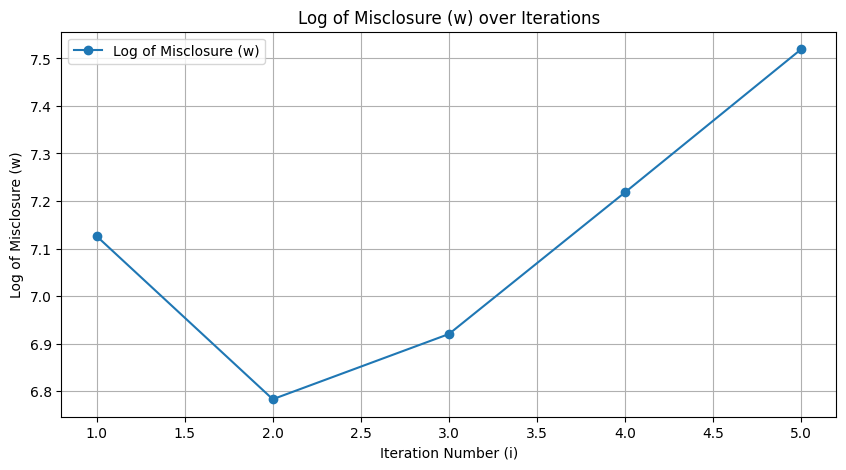

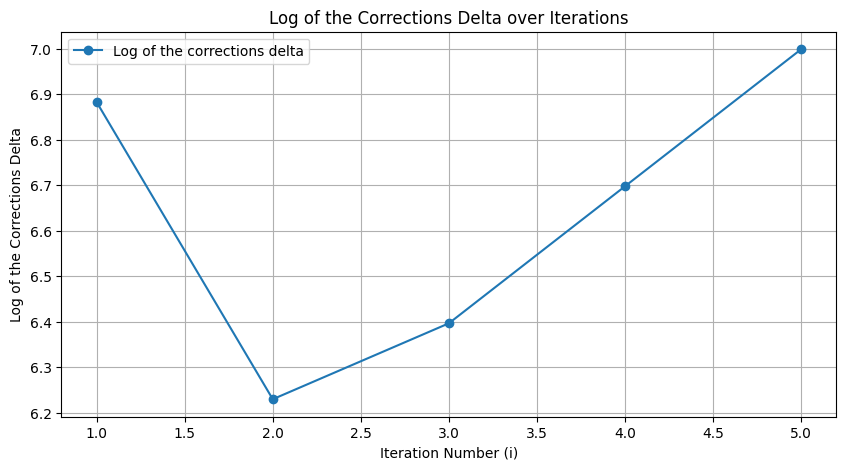

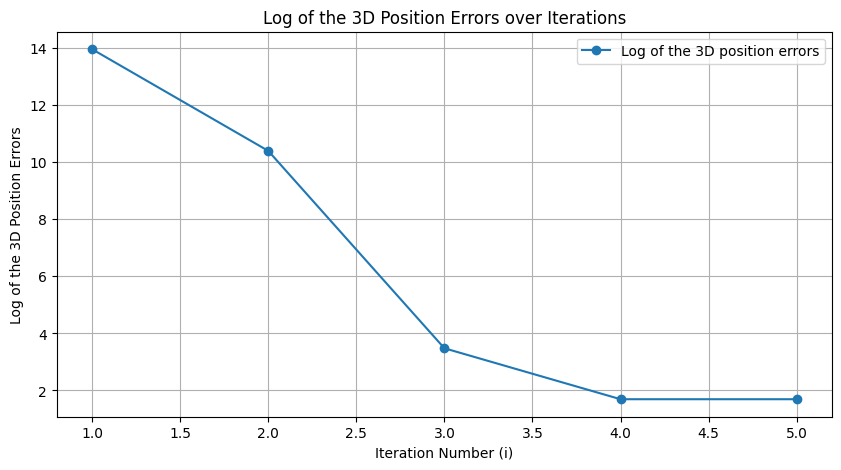

In [15]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)
arr_norm_w = np.linalg.norm(arr_w, axis=1)
log_w = np.log10(arr_norm_w)
plt.figure(figsize=(10, 5))
plt.plot(arr_i, log_w, marker='o', label='Log of Misclosure (w)')
plt.xlabel('Iteration Number (i)')
plt.ylabel('Log of Misclosure (w)')
plt.title('Log of Misclosure (w) over Iterations')
plt.grid(True)
plt.legend()
plt.show()

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
norm_delta = np.linalg.norm(arr_delta, axis=1)
log_delta = np.log10(norm_delta)
plt.figure(figsize=(10,5))
plt.plot(arr_i, log_delta, marker='o', label='Log of the corrections delta')
plt.xlabel('Iteration Number (i)')
plt.ylabel('Log of the Corrections Delta')
plt.title('Log of the Corrections Delta over Iterations')
plt.grid(True)
plt.legend()
plt.show()

# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)
log_err_pos = np.log(arr_err_pos)
plt.figure(figsize=(10,5))
plt.plot(arr_i, log_err_pos, marker='o', label='Log of the 3D position errors')
plt.xlabel('Iteration Number (i)')
plt.ylabel('Log of the 3D Position Errors')
plt.title('Log of the 3D Position Errors over Iterations')
plt.grid(True)
plt.legend()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# your answer here


### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    #...
    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    #...
    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = #...

        # compute the gradients in the current step
        # (1 mark)
        grad = #...


        # update estimates
        # (1 mark)
        X_new = #...

        # compute the new cost
        # (1 mark)
        new_cost = #...

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
optimized_params = #...

# print the mentioned metrics
# ...

### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# ...

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
# ...
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# ...

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
# ...
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# ...

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = #...

# print the metrics
# ...

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = #...

# print the metrics
# ...

### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# your answer here
#

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=[col for col in data.columns if 'id' in col.lower() or 'unnamed' in col.lower()], inplace=True, errors='ignore')  # Remove irrelevant ID column
data.dropna(inplace=True)  # Remove rows with missing values
data.drop_duplicates(inplace=True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
for col in data.select_dtypes(include='object').columns:
    data = data[data[col].str.lower() != 'other']

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("Shape of dataset after preprocessing:", data.shape)
print("\nFirst 5 rows of the cleaned dataset:")
display(data.head())

# Separate features (X) and target (y)
# Find target column automatically if it contains 'depress'
target_col = [col for col in data.columns if 'depress' in col.lower()][0]
X = data.drop(columns=[target_col])
y = data[target_col]

# Print the size of X and y
print("\nSize of X:", X.shape)
print("Size of y:", y.shape)



Shape of dataset after preprocessing: (27898, 16)

First 5 rows of the cleaned dataset:


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,1.0,1.0,No,0



Size of X: (27898, 15)
Size of y: (27898,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
target_col = [col for col in data.columns if 'depress' in col.lower()][0]

y = data[target_col]          # Target vector
X = data.drop(target_col, axis=1)   # Feature matrix

# Display sizes of X and y
print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")

print("\nFirst 5 rows of X:")
print(X.head())

Feature matrix X shape: (27898, 15)
Target vector y shape: (27898,)

First 5 rows of X:
   Gender   Age  City  Profession  Academic Pressure  Work Pressure  CGPA  \
0       1  33.0    51          11                5.0            0.0  8.97   
1       0  24.0     3          11                2.0            0.0  5.90   
2       1  31.0    44          11                3.0            0.0  7.03   
3       0  28.0    49          11                3.0            0.0  5.59   
4       0  25.0    16          11                4.0            0.0  8.13   

   Study Satisfaction  Job Satisfaction  Sleep Duration  Dietary Habits  \
0                 2.0               0.0               0               0   
1                 5.0               0.0               0               1   
2                 5.0               0.0               2               0   
3                 2.0               0.0               1               1   
4                 3.0               0.0               0               1   

### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

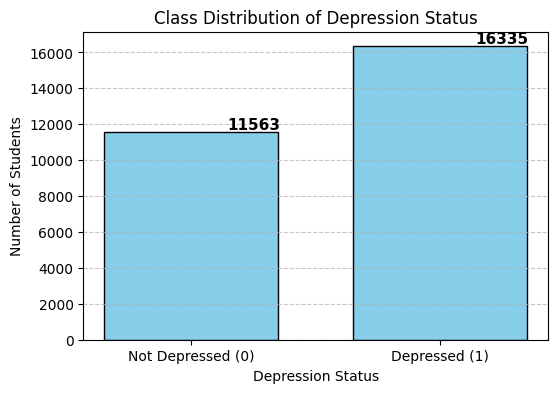

In [ ]:
# Check the class distribution of y
plt.figure(figsize=(6, 4))
counts, bins, patches = plt.hist(y, bins=range(3), align='left', color='skyblue', edgecolor='black', rwidth=0.7)


# Display exact values for each bin in the histogram
for i in range(len(counts)):
    plt.text(bins[i] + 0.25, counts[i] + 1, str(int(counts[i])), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting the chart
plt.xticks([0, 1], ['Not Depressed (0)', 'Depressed (1)'])
plt.xlabel("Depression Status")
plt.ylabel("Number of Students")
plt.title("Class Distribution of Depression Status")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
X_small, _, y_small, _ = train_test_split(X, y, test_size=0.97, random_state=42, stratify=y)

# Display sizes of X_small and y_small (0.5 marks)
print(f"Smaller feature matrix X_small shape: {X_small.shape}")
print(f"Smaller target vector y_small shape: {y_small.shape}")

# Optional check - display first few samples
print("\nFirst 5 rows of X_small:")
print(X_small.head())



Smaller feature matrix X_small shape: (836, 15)
Smaller target vector y_small shape: (836,)

First 5 rows of X_small:
       Gender   Age  City  Profession  Academic Pressure  Work Pressure  CGPA  \
7837        0  18.0    46          11                3.0            0.0  7.85   
9238        1  59.0    37          11                1.0            0.0  8.14   
12189       1  22.0    46          11                3.0            0.0  8.83   
5873        1  20.0    32          11                5.0            0.0  7.25   
5926        0  27.0     9          11                3.0            0.0  7.88   

       Study Satisfaction  Job Satisfaction  Sleep Duration  Dietary Habits  \
7837                  2.0               0.0               2               3   
9238                  1.0               0.0               0               3   
12189                 5.0               0.0               2               3   
5873                  4.0               0.0               3               1   


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 3: Implement Machine Learning Model

# Instantiate the Logistic Regression model
model = LogisticRegression(max_iter=2000, random_state=42)

# 1️ Train/test split for full dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc_full = accuracy_score(y_test, y_pred)
print(f"Accuracy using full dataset: {acc_full:.4f}")

# 2️ Train/test split for first two columns only
X2 = X.iloc[:, :2]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.3, random_state=42, stratify=y)
model.fit(X2_train, y2_train)
y2_pred = model.predict(X2_test)
acc_two_features = accuracy_score(y2_test, y2_pred)
print(f"Accuracy using first two columns: {acc_two_features:.4f}")

# 3️ Train/test split for smaller dataset (3%)
X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(
    X_small, y_small, test_size=0.3, random_state=42, stratify=y_small
)
model.fit(X_small_train, y_small_train)
y_small_pred = model.predict(X_small_test)
acc_small = accuracy_score(y_small_test, y_small_pred)
print(f"Accuracy using smaller dataset (3%): {acc_small:.4f}")

Accuracy using full dataset: 0.8001
Accuracy using first two columns: 0.6300
Accuracy using smaller dataset (3%): 0.8008


### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split

# If you haven't already created these splits, create them now ----
# Full dataset splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# First two columns dataset
X2 = X.iloc[:, :2]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.3, stratify=y, random_state=42)

# Smaller dataset X_small, y_small (from earlier step)
# If X_small,y_small not created yet:
# X_small, _, y_small, _ = train_test_split(X, y, test_size=0.97, random_state=42, stratify=y)
# Then split X_small into train/test:
X_small_train, X_small_test, y_small_train, y_small_test = train_test_split(X_small, y_small, test_size=0.3, stratify=y_small, random_state=42)
# ---------------------------------------------------------------------

# Instantiate three separate LogisticRegression models
model_full = LogisticRegression(max_iter=2000, random_state=42)
model_two  = LogisticRegression(max_iter=2000, random_state=42)
model_small= LogisticRegression(max_iter=2000, random_state=42)

# Fit each model on its corresponding training data
model_full.fit(X_train, y_train)
model_two.fit(X2_train, y2_train)
model_small.fit(X_small_train, y_small_train)

# Predict (train & test) and probabilities for log loss
# ---- Full ----
y_train_pred_full = model_full.predict(X_train)
y_test_pred_full  = model_full.predict(X_test)
y_test_proba_full = model_full.predict_proba(X_test)  # shape (n_samples, n_classes)

# Two features
y_train_pred_two = model_two.predict(X2_train)
y_test_pred_two  = model_two.predict(X2_test)
y_test_proba_two = model_two.predict_proba(X2_test)

#  Small
y_train_pred_small = model_small.predict(X_small_train)
y_test_pred_small  = model_small.predict(X_small_test)
y_test_proba_small = model_small.predict_proba(X_small_test)

# Compute metrics and print them as requested
def print_metrics(name, X_all, X_tr, X_te, y_tr, y_te, y_tr_pred, y_te_pred, y_te_proba):
    print(f"\n=== {name} ===")
    print(f"Data size: {X_all.shape[0]} samples, {X_all.shape[1]} features")
    print(f"Training samples: {X_tr.shape[0]}")
    print(f"Testing samples: {X_te.shape[0]}")
    train_acc = accuracy_score(y_tr, y_tr_pred)
    test_acc  = accuracy_score(y_te, y_te_pred)
    ll = log_loss(y_te, y_te_proba)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy:  {test_acc:.4f}")
    print(f"Log Loss:          {ll:.6f}")

# Print for all three tests
print_metrics("Full dataset", X, X_train, X_test, y_train, y_test, y_train_pred_full, y_test_pred_full, y_test_proba_full)
print_metrics("First two columns", X2, X2_train, X2_test, y2_train, y2_test, y_train_pred_two, y_test_pred_two, y_test_proba_two)
print_metrics("Smaller dataset (3%)", X_small, X_small_train, X_small_test, y_small_train, y_small_test, y_train_pred_small, y_test_pred_small, y_test_proba_small)




=== Full dataset ===
Data size: 27898 samples, 15 features
Training samples: 19528
Testing samples: 8370
Training Accuracy: 0.7948
Testing Accuracy:  0.8001
Log Loss:          0.441188

=== First two columns ===
Data size: 27898 samples, 2 features
Training samples: 19528
Testing samples: 8370
Training Accuracy: 0.6335
Testing Accuracy:  0.6300
Log Loss:          0.653027

=== Smaller dataset (3%) ===
Data size: 836 samples, 15 features
Training samples: 585
Testing samples: 251
Training Accuracy: 0.8120
Testing Accuracy:  0.8008
Log Loss:          0.437752


### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import pandas as pd
# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000, random_state=0)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                                "Training accuracy", "Testing accuracy", "Log loss"])

# Function Definition
def evaluate_model(X_data, y_data, model, results_df, label):
    # Split data (70% train, 30% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.3, stratify=y_data, random_state=0
    )

    # Train model
    model.fit(X_train, y_train)

    # Predictions and probabilities
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    loss      = log_loss(y_test, y_test_proba)

    # Add to results DataFrame
    results_df.loc[label] = [
        len(X_data),
        len(X_train),
        len(X_test),
        train_acc,
        test_acc,
        loss
    ]

    return results_df

# Test 1: Full dataset ----
results = evaluate_model(X, y, model, results, "Full dataset")

# Test 2: Only first two columns ----
X_two = X.iloc[:, :2]
results = evaluate_model(X_two, y, model, results, "First two columns")

# Test 3: Smaller dataset (3%) ----
results = evaluate_model(X_small, y_small, model, results, "Smaller dataset (3%)")


print("\n=== Step 5.1: Model Evaluation Results ===")
display(results)



=== Step 5.1: Model Evaluation Results ===


,Data size,Training samples,Testing samples,Training accuracy,Testing accuracy,Log loss
Full dataset,27898.0,19528.0,8370.0,0.793937,0.800478,0.436350
First two columns,27898.0,19528.0,8370.0,0.631811,0.633931,0.652386
Smaller dataset (3%),836.0,585.0,251.0,0.823932,0.772908,0.492569


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Split full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0
)
# Train logistic regression model
model = LogisticRegression(max_iter=2000, random_state=0)
model.fit(X_train, y_train)

# Retrieve predicted values
y_test_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\n=== Confusion Matrix (Full Dataset) ===")
print(cm)

# Classification Report
print("\n=== Classification Report (Full Dataset) ===")
print(classification_report(y_test, y_test_pred, digits=4))



=== Confusion Matrix (Full Dataset) ===
[[2574  895]
 [ 775 4126]]

=== Classification Report (Full Dataset) ===
              precision    recall  f1-score   support

           0     0.7686    0.7420    0.7551      3469
           1     0.8217    0.8419    0.8317      4901

    accuracy                         0.8005      8370
   macro avg     0.7952    0.7919    0.7934      8370
weighted avg     0.7997    0.8005    0.7999      8370



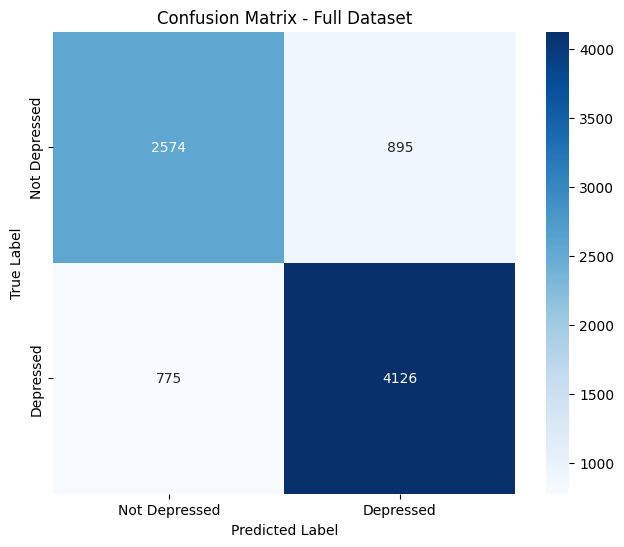

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_test, y_test_pred)


# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted Label'   )
plt.ylabel( 'True Label'  )
plt.title('Confusion Matrix - Full Dataset')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print("\n=== Classification Report - Full Dataset ===")
print(classification_report(y_test, y_test_pred, target_names=['Not Depressed', 'Depressed'], digits=4))



=== Classification Report - Full Dataset ===
               precision    recall  f1-score   support

Not Depressed     0.7686    0.7420    0.7551      3469
    Depressed     0.8217    0.8419    0.8317      4901

     accuracy                         0.8005      8370
    macro avg     0.7952    0.7919    0.7934      8370
 weighted avg     0.7997    0.8005    0.7999      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=0),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train, y_train)

    # Make predictions
    y_pred = model_instance.predict(X_test)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    # Save results
    model_results[name] = acc

    # Print results
    print(f"{name} Accuracy: {acc:.4f}")

    model_comparison = pd.DataFrame.from_dict(model_results, orient='index', columns=['Accuracy'])
    print("\n=== Model Accuracy Comparison ===")
    display(model_comparison)


Logistic Regression Accuracy: 0.8005

=== Model Accuracy Comparison ===


,Accuracy
Logistic Regression,0.800478


Naive Bayes Accuracy: 0.5202

=== Model Accuracy Comparison ===


,Accuracy
Logistic Regression,0.800478
Naive Bayes,0.520191


K-Nearest Neighbors Accuracy: 0.7384

=== Model Accuracy Comparison ===


,Accuracy
Logistic Regression,0.800478
Naive Bayes,0.520191
K-Nearest Neighbors,0.738351


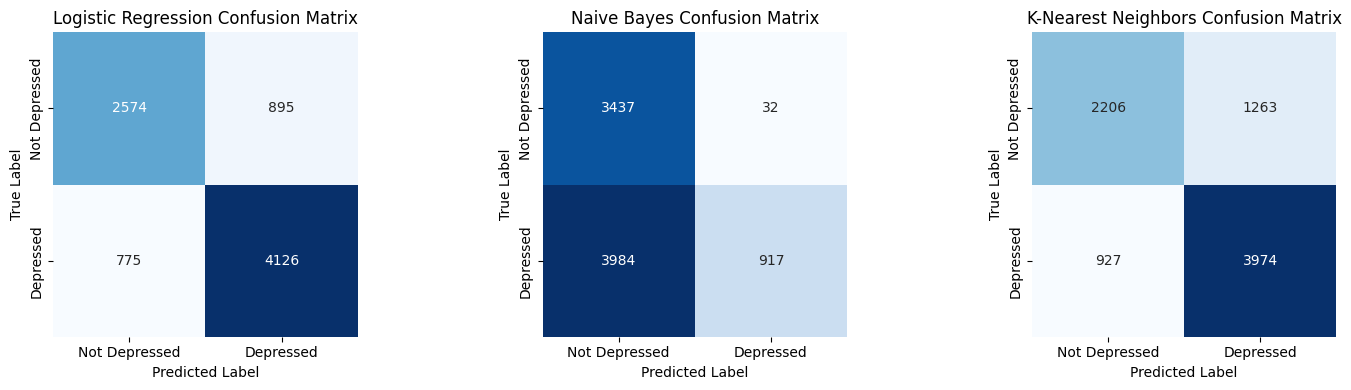

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))

# Loop through models and plot their confusion matrices
for i, (name, model_instance) in enumerate(models.items(), 1):
    # Predict using the model
    y_pred = model_instance.predict(X_test)

    # Calculate confusion matrix
    conf_mat = confusion_matrix(y_test, y_pred)

    # Plot heatmap
    plt.subplot(1, 3, i)
    sns.heatmap(conf_mat,
                annot=True,
                fmt='d',
                cmap='Blues',
                square=True,
                cbar=False,
                xticklabels=['Not Depressed', 'Depressed'],
                yticklabels=['Not Depressed', 'Depressed'])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

The dataset used in this project is not perfectly balanced, meaning that one group of students (for example, those who are not depressed) appears more often than the other group. This imbalance can make it harder for models to recognize the minority class — in this case, the depressed students. As a result, models may seem to perform well overall but actually fail to detect some students who are struggling.

When looking at the three tests, the models showed different behaviors. Using the full dataset gave the most balanced results — not overfitted and not underfitted. When only the first two features were used, the model didn’t have enough information to learn properly, so it underfitted the data. In contrast, when a very small dataset was used, the model learned the training data too closely and performed worse on unseen data — a classic sign of overfitting.

As expected, the training and testing accuracy changed depending on how much data was available. With a small dataset, the training accuracy was high, but the testing accuracy dropped significantly, showing poor generalization. As the amount of data increased, the model became more stable — both training and testing accuracy got closer together. For instance, the model trained on the full dataset achieved similar accuracy on both training and testing data, showing good generalization.

In this study, a false positive means predicting that a student is depressed when they are actually not, while a false negative means missing a student who truly is depressed. Between the two, false negatives are more serious because they represent students who need help but might not get it due to an incorrect prediction.

Because of that, it’s better to maximize recall rather than precision. Maximizing recall helps ensure that most of the truly depressed students are identified, even if it means we might occasionally flag some students who aren’t actually depressed. This can be done by adjusting the model’s decision threshold or by applying class weights to reduce the imbalance problem.

When we look at log loss, lower values indicate that the model is making confident and accurate predictions, while higher values mean it’s more uncertain. The full dataset produced the lowest log loss, showing that the model had enough data to make confident predictions. The small dataset, on the other hand, resulted in the highest log loss — likely because it lacked enough data to generalize well.

Finally, when comparing different algorithms, Logistic Regression performed the best overall. It’s a strong model for binary classification and handles continuous variables well. Naive Bayes was slightly behind — it’s simple and fast, but assumes that all features are independent, which isn’t always true in real data. K-Nearest Neighbors (KNN) had the lowest accuracy, probably because it’s sensitive to the scale of data and works less effectively when there are many features or noise.

In conclusion, Logistic Regression provided the most consistent and reliable results, while Naive Bayes and KNN showed some limitations. Having a balanced dataset and enough features clearly improves model stability and predictive power.


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

In [2]:

# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
import os
print(os.getcwd())
os.chdir("/Users/leilatawfik/Desktop/FALL 2025/ENGG680_2025_Fall")

/Users/leilatawfik/Desktop/FALL 2025/ENGG680_2025_Fall/Lab_Assignment2


### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [5]:
# Load MNIST dataset from CSV files
train_csv_path = "Lab_Assignment2/part3_data/mnist_train.csv"
test_csv_path = "Lab_Assignment2/part3_data/mnist_test.csv"

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
# all rows but only the first column, because it contains the label we are predicting
y_train = train_data.iloc[:, 0]
# all columns after the label
X_train = train_data.iloc[:,1:]

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.to_numpy().reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0]
X_test = test_data.iloc[:,1:]

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.to_numpy().reshape(-1, 28, 28)

# Display the shapes of training and test sets
print("Training data shape:", X_train.shape, y_train.shape)
print("Test data shape:", X_test.shape, y_test.shape)

Training data shape: (60000, 28, 28) (60000,)
Test data shape: (10000, 28, 28) (10000,)


Let's visualize some sample images to understand what our models will be learning from.

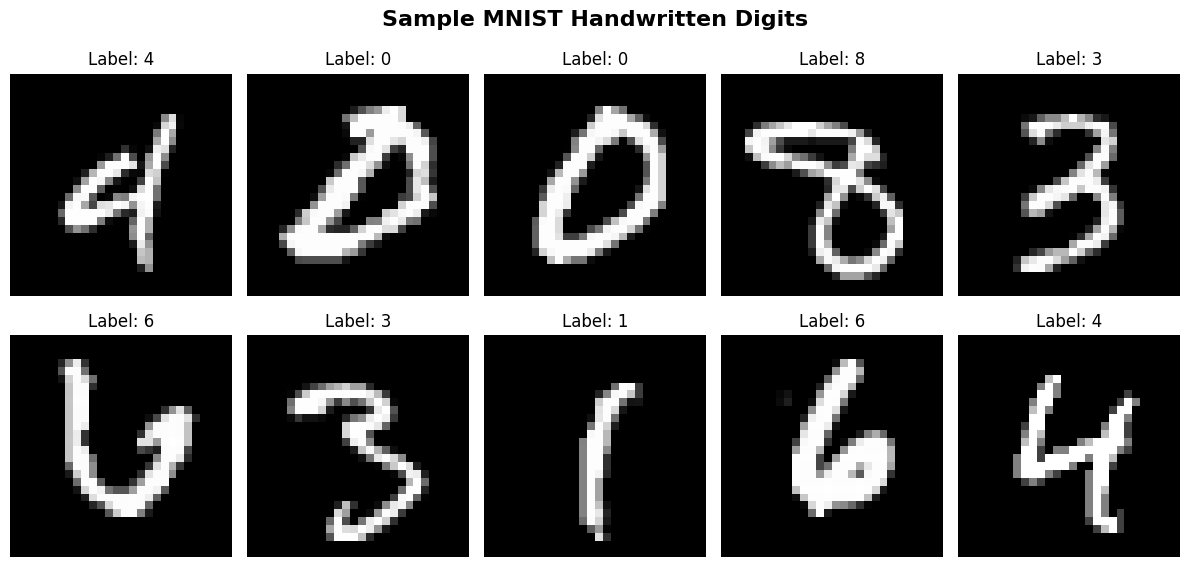

In [6]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [7]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical =  keras.utils.to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [13]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),


        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(num_classes, activation='softmax')


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


**Use .fit() to train MLP model**

In [14]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [15]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


**Use .fit() to train CNN model**

In [16]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [19]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
mlp_predictions = mlp_model.predict(X_test_normalized)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical, verbose=0)
cnn_predictions = cnn_model.predict(X_test_normalized)

# Similarly, convert CNN predicted probabilities to class labels
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)


# Display Results
print("MLP Test Loss:", mlp_test_loss)
print("MLP Test Accuracy:", mlp_test_accuracy)
print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_accuracy)




313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MLP Test Loss: 0.08282092958688736
MLP Test Accuracy: 0.9757000207901001
CNN Test Loss: 0.03013000451028347
CNN Test Accuracy: 0.991100013256073


Performance comparison visualization

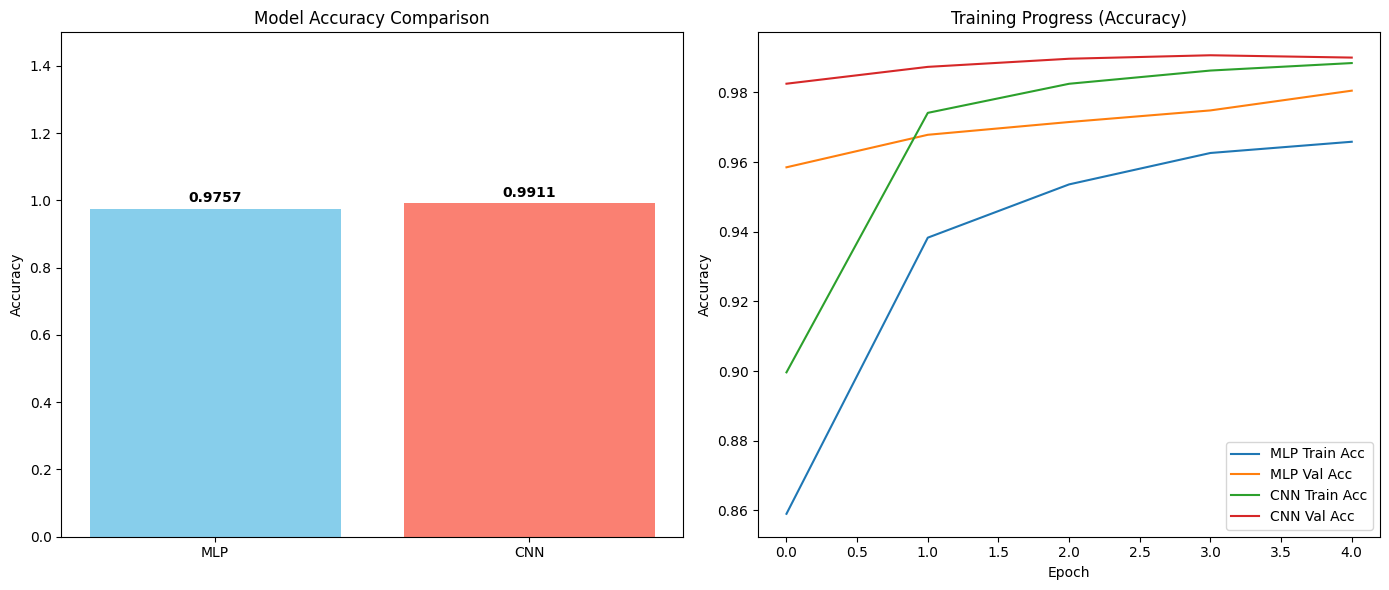

In [21]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
models = ['MLP', 'CNN']
accuracies = [mlp_test_accuracy, cnn_test_accuracy]

# Bar chart for accuracy comparison
ax1.bar(models, accuracies, color=['skyblue', 'salmon'])
ax1.set_title('Model Accuracy Comparison')      
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.5)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
        

# MLP history
mlp_acc = mlp_history.history['accuracy']
mlp_val_acc = mlp_history.history['val_accuracy']
mlp_loss = mlp_history.history['loss']
mlp_val_loss = mlp_history.history['val_loss']

# CNN history
cnn_acc = cnn_history.history['accuracy']
cnn_val_acc = cnn_history.history['val_accuracy']
cnn_loss = cnn_history.history['loss']
cnn_val_loss = cnn_history.history['val_loss']

# Plot accuracy curves
ax2.plot(mlp_acc, label='MLP Train Acc')
ax2.plot(mlp_val_acc, label='MLP Val Acc')
ax2.plot(cnn_acc, label='CNN Train Acc')
ax2.plot(cnn_val_acc, label='CNN Val Acc')

ax2.set_title('Training Progress (Accuracy)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

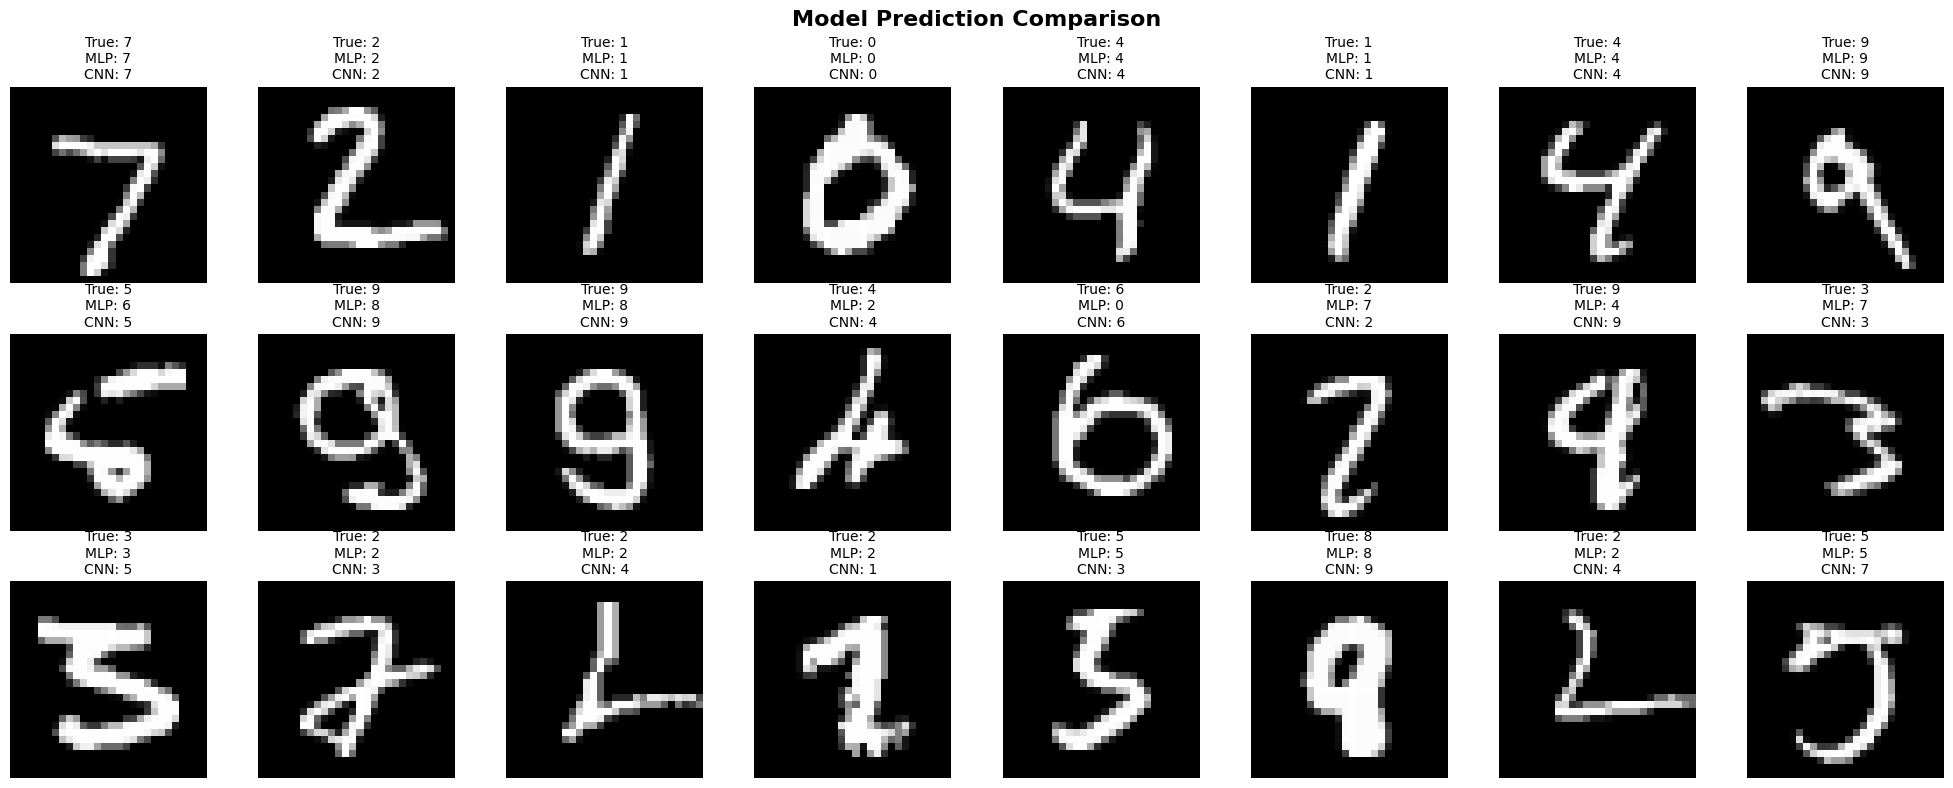

In [22]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle('Model Prediction Comparison', fontsize=16, fontweight='bold')

# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)
# Sample for cnn_correct_mlp_wrong
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]
# your code here (1 marks)
# Sample for mlp_correct_cnn_wrong
mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]      
# Plot both models correct
for i, idx in enumerate(both_correct_indices):
    axes[0, i].imshow(X_test[idx], cmap='gray')
    axes[0, i].set_title(f'True: {y_test.iloc[idx]}\nMLP: {mlp_predicted_classes[idx]}\nCNN: {cnn_predicted_classes[idx]}', fontsize=10)
    axes[0, i].axis('off')          

# Plot CNN correct, MLP wrong
for i, idx in enumerate(cnn_correct_mlp_wrong_indices):
    axes[1, i].imshow(X_test[idx], cmap='gray')
    axes[1, i].set_title(f'True: {y_test.iloc[idx]}\nMLP: {mlp_predicted_classes[idx]}\nCNN: {cnn_predicted_classes[idx]}', fontsize=10)
    axes[1, i].axis('off')      
# Plot MLP correct, CNN wrong
for i, idx in enumerate(mlp_correct_cnn_wrong_indices):
    axes[2, i].imshow(X_test[idx], cmap='gray')
    axes[2, i].set_title(f'True: {y_test.iloc[idx]}\nMLP: {mlp_predicted_classes[idx]}\nCNN: {cnn_predicted_classes[idx]}', fontsize=10)
    axes[2, i].axis('off')  




# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)
plt.tight_layout()

plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)
